In [1]:
import pandas as pd

order_fact = pd.read_parquet("../data_processed/order_fact.parquet")

order_fact.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,gmv,item_cnt,payment_total,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_month
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,38.71,1.0,38.71,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,2017-10
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,141.46,1.0,141.46,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,2018-07
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,179.12,1.0,179.12,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,2018-08
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,72.20,1.0,72.20,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,2017-11
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,28.62,1.0,28.62,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,2018-02


构建“首购月”

In [2]:
order_fact['order_purchase_timestamp'] = pd.to_datetime(order_fact['order_purchase_timestamp'])

# 用户首购时间
first_purchase = (
    order_fact
    .groupby('customer_unique_id')['order_purchase_timestamp']
    .min()
    .reset_index()
)

first_purchase.columns = ['customer_unique_id', 'first_purchase_date']

# 合并回原表
order_fact = order_fact.merge(first_purchase, on='customer_unique_id')

# 提取首购月
order_fact['cohort_month'] = order_fact['first_purchase_date'].dt.to_period('M')
order_fact['order_month'] = order_fact['order_purchase_timestamp'].dt.to_period('M')

order_fact.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,gmv,item_cnt,payment_total,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_month,first_purchase_date,cohort_month
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,38.71,1.0,38.71,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,2017-10,2017-09-04 11:26:38,2017-09
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,141.46,1.0,141.46,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,2018-07,2018-07-24 20:41:37,2018-07
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,179.12,1.0,179.12,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,2018-08,2018-08-08 08:38:49,2018-08
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,72.20,1.0,72.20,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,2017-11,2017-11-18 19:28:06,2017-11
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,28.62,1.0,28.62,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,2018-02,2018-02-13 21:18:39,2018-02


计算用户在第几个月

In [3]:
order_fact['cohort_index'] = (
    order_fact['order_month'].astype(int)
    - order_fact['cohort_month'].astype(int)
)

构建cohort表

In [4]:
cohort_data = (
    order_fact
    .groupby(['cohort_month', 'cohort_index'])
    ['customer_unique_id']
    .nunique()
    .reset_index()
)

cohort_pivot = cohort_data.pivot(
    index='cohort_month',
    columns='cohort_index',
    values='customer_unique_id'
)

cohort_pivot

cohort_index,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,19,20
cohort_month,,,,,,,,,,,,,,,,,,,,
2016-09,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-10,321.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,1.0,NaN,1.0,NaN,1.0,NaN,1.0,NaN,1.0,2.0,2.0
2016-12,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-01,764.0,3.0,2.0,1.0,3.0,1.0,4.0,1.0,1.0,NaN,3.0,1.0,6.0,3.0,1.0,1.0,2.0,3.0,1.0,NaN
2017-02,1752.0,4.0,5.0,2.0,7.0,2.0,4.0,3.0,3.0,4.0,2.0,5.0,3.0,3.0,2.0,1.0,1.0,4.0,NaN,NaN
2017-03,2636.0,13.0,10.0,10.0,9.0,4.0,4.0,8.0,9.0,2.0,10.0,4.0,6.0,3.0,4.0,6.0,2.0,4.0,NaN,NaN
2017-04,2352.0,14.0,5.0,4.0,8.0,6.0,8.0,7.0,7.0,4.0,6.0,2.0,2.0,1.0,2.0,2.0,5.0,NaN,NaN,NaN
2017-05,3596.0,18.0,18.0,14.0,11.0,12.0,15.0,6.0,9.0,11.0,9.0,12.0,9.0,1.0,7.0,9.0,NaN,NaN,NaN,NaN
2017-06,3139.0,15.0,11.0,13.0,8.0,12.0,12.0,7.0,4.0,7.0,10.0,11.0,5.0,4.0,6.0,NaN,NaN,NaN,NaN,NaN


转为留存率

In [5]:
cohort_size = cohort_pivot.iloc[:, 0]

retention = cohort_pivot.divide(cohort_size, axis=0)

retention

cohort_index,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,19,20
cohort_month,,,,,,,,,,,,,,,,,,,,
2016-09,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-10,1.0,NaN,NaN,NaN,NaN,NaN,0.003115,NaN,NaN,0.003115,NaN,0.003115,NaN,0.003115,NaN,0.003115,NaN,0.003115,0.006231,0.006231
2016-12,1.0,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-01,1.0,0.003927,0.002618,0.001309,0.003927,0.001309,0.005236,0.001309,0.001309,NaN,0.003927,0.001309,0.007853,0.003927,0.001309,0.001309,0.002618,0.003927,0.001309,NaN
2017-02,1.0,0.002283,0.002854,0.001142,0.003995,0.001142,0.002283,0.001712,0.001712,0.002283,0.001142,0.002854,0.001712,0.001712,0.001142,0.000571,0.000571,0.002283,NaN,NaN
2017-03,1.0,0.004932,0.003794,0.003794,0.003414,0.001517,0.001517,0.003035,0.003414,0.000759,0.003794,0.001517,0.002276,0.001138,0.001517,0.002276,0.000759,0.001517,NaN,NaN
2017-04,1.0,0.005952,0.002126,0.001701,0.003401,0.002551,0.003401,0.002976,0.002976,0.001701,0.002551,0.000850,0.000850,0.000425,0.000850,0.000850,0.002126,NaN,NaN,NaN
2017-05,1.0,0.005006,0.005006,0.003893,0.003059,0.003337,0.004171,0.001669,0.002503,0.003059,0.002503,0.003337,0.002503,0.000278,0.001947,0.002503,NaN,NaN,NaN,NaN
2017-06,1.0,0.004779,0.003504,0.004141,0.002549,0.003823,0.003823,0.002230,0.001274,0.002230,0.003186,0.003504,0.001593,0.001274,0.001911,NaN,NaN,NaN,NaN,NaN


In [6]:
cohort_size = cohort_pivot.iloc[:, 0].rename("cohort_size")
cohort_size.describe()

count      25.000000
mean     3843.840000
std      2603.185447
min         1.000000
25%      1752.000000
50%      4130.000000
75%      6271.000000
max      7304.000000
Name: cohort_size, dtype: float64

In [7]:
min_size = 200
retention_filtered = retention.loc[cohort_size[cohort_size >= min_size].index]
retention_filtered.head()

cohort_index,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,19,20
cohort_month,,,,,,,,,,,,,,,,,,,,
2016-10,1.0,NaN,NaN,NaN,NaN,NaN,0.003115,NaN,NaN,0.003115,NaN,0.003115,NaN,0.003115,NaN,0.003115,NaN,0.003115,0.006231,0.006231
2017-01,1.0,0.003927,0.002618,0.001309,0.003927,0.001309,0.005236,0.001309,0.001309,NaN,0.003927,0.001309,0.007853,0.003927,0.001309,0.001309,0.002618,0.003927,0.001309,NaN
2017-02,1.0,0.002283,0.002854,0.001142,0.003995,0.001142,0.002283,0.001712,0.001712,0.002283,0.001142,0.002854,0.001712,0.001712,0.001142,0.000571,0.000571,0.002283,NaN,NaN
2017-03,1.0,0.004932,0.003794,0.003794,0.003414,0.001517,0.001517,0.003035,0.003414,0.000759,0.003794,0.001517,0.002276,0.001138,0.001517,0.002276,0.000759,0.001517,NaN,NaN
2017-04,1.0,0.005952,0.002126,0.001701,0.003401,0.002551,0.003401,0.002976,0.002976,0.001701,0.002551,0.000850,0.000850,0.000425,0.000850,0.000850,0.002126,NaN,NaN,NaN


In [8]:
retention_for_plot = retention_filtered.fillna(0)

In [9]:
avg_retention = retention_filtered.mean()

avg_retention

cohort_index
0     1.000000
1     0.004812
2     0.003072
3     0.002552
4     0.002737
5     0.002266
6     0.002691
7     0.002102
8     0.002131
9     0.001946
10    0.002648
11    0.002221
12    0.002378
13    0.001805
14    0.001446
15    0.001771
16    0.001518
17    0.002711
19    0.003770
20    0.006231
dtype: float64

过滤delivered

In [10]:
order_fact_delivered = order_fact[order_fact["order_status"] == "delivered"].copy()

In [11]:
cohort_data_delivered = (
    order_fact_delivered
    .groupby(['cohort_month', 'cohort_index'])
    ['customer_unique_id']
    .nunique()
    .reset_index()
)

cohort_pivot_delivered = cohort_data_delivered.pivot(
    index='cohort_month',
    columns='cohort_index',
    values='customer_unique_id'
)

cohort_pivot_delivered

cohort_index,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,19,20
cohort_month,,,,,,,,,,,,,,,,,,,,
2016-09,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-10,262.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,1.0,NaN,1.0,NaN,1.0,NaN,1.0,NaN,1.0,2.0,2.0
2016-12,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-01,717.0,3.0,2.0,1.0,3.0,1.0,3.0,1.0,1.0,NaN,3.0,1.0,5.0,3.0,1.0,1.0,2.0,3.0,1.0,NaN
2017-02,1627.0,4.0,5.0,2.0,7.0,2.0,4.0,3.0,3.0,4.0,2.0,5.0,3.0,3.0,2.0,1.0,1.0,4.0,NaN,NaN
2017-03,2502.0,13.0,9.0,10.0,9.0,4.0,4.0,8.0,9.0,2.0,9.0,3.0,6.0,3.0,4.0,6.0,2.0,4.0,NaN,NaN
2017-04,2254.0,14.0,5.0,4.0,7.0,6.0,8.0,7.0,7.0,4.0,6.0,2.0,2.0,1.0,2.0,2.0,5.0,NaN,NaN,NaN
2017-05,3451.0,18.0,18.0,13.0,11.0,12.0,15.0,6.0,9.0,9.0,9.0,12.0,9.0,1.0,7.0,9.0,NaN,NaN,NaN,NaN
2017-06,3035.0,15.0,11.0,12.0,8.0,11.0,12.0,7.0,4.0,7.0,10.0,10.0,5.0,4.0,6.0,NaN,NaN,NaN,NaN,NaN


In [12]:
cohort_size_delivered = cohort_pivot_delivered.iloc[:, 0]

retention_delivered = cohort_pivot_delivered.divide(cohort_size_delivered, axis=0)

retention_delivered

cohort_index,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,19,20
cohort_month,,,,,,,,,,,,,,,,,,,,
2016-09,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-10,1.0,NaN,NaN,NaN,NaN,NaN,0.003817,NaN,NaN,0.003817,NaN,0.003817,NaN,0.003817,NaN,0.003817,NaN,0.003817,0.007634,0.007634
2016-12,1.0,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-01,1.0,0.004184,0.002789,0.001395,0.004184,0.001395,0.004184,0.001395,0.001395,NaN,0.004184,0.001395,0.006974,0.004184,0.001395,0.001395,0.002789,0.004184,0.001395,NaN
2017-02,1.0,0.002459,0.003073,0.001229,0.004302,0.001229,0.002459,0.001844,0.001844,0.002459,0.001229,0.003073,0.001844,0.001844,0.001229,0.000615,0.000615,0.002459,NaN,NaN
2017-03,1.0,0.005196,0.003597,0.003997,0.003597,0.001599,0.001599,0.003197,0.003597,0.000799,0.003597,0.001199,0.002398,0.001199,0.001599,0.002398,0.000799,0.001599,NaN,NaN
2017-04,1.0,0.006211,0.002218,0.001775,0.003106,0.002662,0.003549,0.003106,0.003106,0.001775,0.002662,0.000887,0.000887,0.000444,0.000887,0.000887,0.002218,NaN,NaN,NaN
2017-05,1.0,0.005216,0.005216,0.003767,0.003187,0.003477,0.004347,0.001739,0.002608,0.002608,0.002608,0.003477,0.002608,0.000290,0.002028,0.002608,NaN,NaN,NaN,NaN
2017-06,1.0,0.004942,0.003624,0.003954,0.002636,0.003624,0.003954,0.002306,0.001318,0.002306,0.003295,0.003295,0.001647,0.001318,0.001977,NaN,NaN,NaN,NaN,NaN


In [13]:
min_size = 200
retention_delivered_filtered = retention_delivered.loc[cohort_size_delivered[cohort_size_delivered >= min_size].index]
retention_delivered_filtered.head()

cohort_index,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,19,20
cohort_month,,,,,,,,,,,,,,,,,,,,
2016-10,1.0,NaN,NaN,NaN,NaN,NaN,0.003817,NaN,NaN,0.003817,NaN,0.003817,NaN,0.003817,NaN,0.003817,NaN,0.003817,0.007634,0.007634
2017-01,1.0,0.004184,0.002789,0.001395,0.004184,0.001395,0.004184,0.001395,0.001395,NaN,0.004184,0.001395,0.006974,0.004184,0.001395,0.001395,0.002789,0.004184,0.001395,NaN
2017-02,1.0,0.002459,0.003073,0.001229,0.004302,0.001229,0.002459,0.001844,0.001844,0.002459,0.001229,0.003073,0.001844,0.001844,0.001229,0.000615,0.000615,0.002459,NaN,NaN
2017-03,1.0,0.005196,0.003597,0.003997,0.003597,0.001599,0.001599,0.003197,0.003597,0.000799,0.003597,0.001199,0.002398,0.001199,0.001599,0.002398,0.000799,0.001599,NaN,NaN
2017-04,1.0,0.006211,0.002218,0.001775,0.003106,0.002662,0.003549,0.003106,0.003106,0.001775,0.002662,0.000887,0.000887,0.000444,0.000887,0.000887,0.002218,NaN,NaN,NaN


In [14]:
retention_delivered_for_plot = retention_filtered.fillna(0)

In [15]:
avg_retention_delivered = retention_delivered_filtered.mean()

avg_retention_delivered

cohort_index
0     1.000000
1     0.005018
2     0.003432
3     0.002583
4     0.002940
5     0.002303
6     0.002736
7     0.002188
8     0.002209
9     0.002007
10    0.002727
11    0.002280
12    0.002335
13    0.001937
14    0.001519
15    0.001953
16    0.001605
17    0.003015
19    0.004514
20    0.007634
dtype: float64

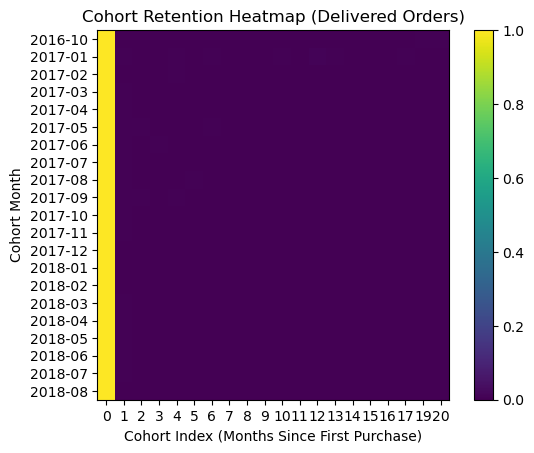

In [16]:
import matplotlib.pyplot as plt
import numpy as np

# 转为 numpy 矩阵
data = retention_delivered_for_plot.values

plt.figure()
plt.imshow(data)

plt.xticks(
    ticks=np.arange(data.shape[1]),
    labels=retention_delivered_for_plot.columns
)

plt.yticks(
    ticks=np.arange(data.shape[0]),
    labels=retention_delivered_for_plot.index.astype(str)
)

plt.xlabel("Cohort Index (Months Since First Purchase)")
plt.ylabel("Cohort Month")
plt.title("Cohort Retention Heatmap (Delivered Orders)")

plt.colorbar()

plt.show()